In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import yaml

import data_prep as dp

# Paths
DATA_PATH = "Baltalimani_Data_2025.xlsx"
DEPT_MAPPING_PATH = "Baltalimani_Data_2025.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Reproducibility — seed for any random sampling (jitter, QA draws, etc.)
RNG = np.random.default_rng(42)

# Plotting defaults
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Polyclinic appointment schedules — kept here (and not hardcoded inside
# simulation.py) so we can tweak them in the notebook before they get written
# into config.yml. Mirrors arrivals.appointment.schedules in config.yml.
APPOINTMENT_SCHEDULES = {
    "schedule_1": {
        "description": "Every 6 min, 08:00-12:00 and 13:00-16:00",
        "windows": [
            {"start": "08:00", "end": "12:00", "interval_minutes": 6},
            {"start": "13:00", "end": "16:00", "interval_minutes": 6},
        ],
    },
    "schedule_2": {
        "description": "Mixed intervals by block",
        "windows": [
            {"start": "08:00", "end": "10:00", "interval_minutes": 6},
            {"start": "10:00", "end": "12:00", "interval_minutes": 8},
            {"start": "13:00", "end": "15:00", "interval_minutes": 8},
            {"start": "15:00", "end": "16:00", "interval_minutes": 10},
        ],
    },
    "schedule_3": {
        "description": "Morning only: 6 min then 8 min",
        "windows": [
            {"start": "08:00", "end": "10:00", "interval_minutes": 6},
            {"start": "10:00", "end": "12:00", "interval_minutes": 8},
        ],
    },
}


In [2]:
raw = dp.load_raw(DATA_PATH)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.dtypes.to_frame("dtype")

Raw shape: 12,263 rows x 13 columns


,dtype
HASTA_ADI_SOYADI,str
TC_KIMLIK_NO,str
CINSIYET,str
DOKTOR_ADI,str
DOGUM_YILI,int64
GIRIS_TARIHI,datetime64[us]
RANDEVU_BASLAMA_SAATI,datetime64[us]
MUAYENE_KABUL_ZAMANI,datetime64[us]
CAGRILMA_ZAMANI,datetime64[us]
TETKIK_ISTEK_SAATI,datetime64[us]


In [3]:
missing = raw.isna().sum().to_frame("missing")
missing["missing_pct"] = (missing["missing"] / len(raw) * 100).round(2)
missing.sort_values("missing", ascending=False)

,missing,missing_pct
RONTGEN_ODA_NO,5087,41.48
CEKIM_ZAMANI,5064,41.29
TETKIK_ISTEK_SAATI,4935,40.24
CAGRILMA_ZAMANI,3466,28.26
MUAYENE_SONLANDIRMA_ZAMANI,1095,8.93
MUAYENE_KABUL_ZAMANI,586,4.78
DOGUM_YILI,0,0.00
CINSIYET,0,0.00
TC_KIMLIK_NO,0,0.00
HASTA_ADI_SOYADI,0,0.00


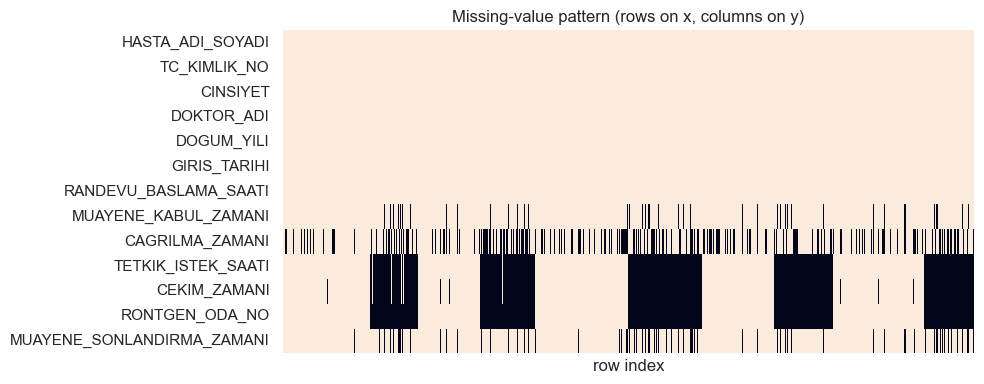

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(raw.isna().T, cbar=False, ax=ax, cmap="rocket_r")
ax.set_title("Missing-value pattern (rows on x, columns on y)")
ax.set_xlabel("row index")
ax.set_xticks([])
fig.tight_layout()
fig.savefig(OUT_DIR / "missing_value_heatmap.png", dpi=150)
plt.show()

## 2. Cleaning audit

The cleaning pipeline runs in 10 deterministic steps. The audit table below reports how many rows each step consumed or masked; copy it verbatim into the report appendix.

In [5]:
doctor_to_department = dp.load_doctor_department_mapping(DEPT_MAPPING_PATH)
all_departments = {d for specs in doctor_to_department.values() for d in specs}
multi_specialty_doctors = {d: specs for d, specs in doctor_to_department.items() if len(specs) > 1}

print(f"Loaded mapping: {len(doctor_to_department)} doctors -> {len(all_departments)} distinct specialties")
print(f"Doctors with >1 specialty: {len(multi_specialty_doctors)}")
if multi_specialty_doctors:
    for doc, specs in sorted(multi_specialty_doctors.items()):
        print(f"  {doc}: {specs}")

df, log = dp.load_and_clean(DATA_PATH, doctor_to_department=doctor_to_department)

unmapped = sorted(set(df["DOKTOR_ADI"].unique()) - set(doctor_to_department))
if unmapped:
    print(f"\nWARNING: {len(unmapped)} doctors in data but not in the mapping CSV: {unmapped}")
else:
    print("\nAll doctors in the data are present in the mapping CSV.")

audit = log.to_frame()
audit.to_csv(OUT_DIR / "cleaning_audit.csv", index=False)

audit_df = pd.DataFrame(audit)
pd.set_option('display.max_colwidth', None)
audit_df.head(20)

Loaded mapping: 32 doctors -> 9 distinct specialties
Doctors with >1 specialty: 12
  AHMET FIRAT BERKAY: ['ShoulderSports', 'KneeMeniscus']
  AHMET KOCABIYIK: ['AdultHipKnee', 'BoneDeformity']
  BARIŞ ÇAYPINAR: ['AdultHipKnee', 'Spine']
  BARIŞ ÖZKUL: ['AdultHipKnee', 'BoneDeformity']
  DENİZ KARGIN: ['AdultHipKnee', 'Spine']
  GÖKHAN PEHLİVANOĞLU: ['ShoulderSports', 'KneeMeniscus']
  KADİR İLKER YILDIZ: ['ShoulderSports', 'KneeMeniscus']
  MEHMET ÖZBEY BÜYÜKKUŞCU: ['ShoulderSports', 'KneeMeniscus']
  MUSTAFA SERPİ: ['ShoulderSports', 'KneeMeniscus']
  NİYAZİ İĞDE: ['BoneCyst', 'Tumor']
  OSMAN EMRE AYCAN: ['BoneCyst', 'Tumor']
  ULAŞ YAVUZ: ['ShoulderSports', 'KneeMeniscus']

All doctors in the data are present in the mapping CSV.


,step,rows_before,rows_after,delta,note
0,load_raw,12263,12263,0,Loaded 12263 raw rows from Baltalimani_Data_2025.xlsx
1,drop_cekim_without_rontgen_room,12263,12119,144,Removed rows with CEKIM_ZAMANI set but RONTGEN_ODA_NO missing.
2,drop_tetkik_without_muayene_kabul,12119,12009,110,Removed rows with TETKIK_ISTEK_SAATI set but MUAYENE_KABUL_ZAMANI missing.
3,consolidate_xray_duplicates,12009,1920,10089,"Multi-angle X-ray shots collapsed to one visit per (patient, day, doctor)."
4,drop_room_160,1920,1862,58,Removed 58 scoliosis rows (room suffix 160).
5,flag_call_time_anomaly,1862,1862,0,Masked 583 call-time values that were overwritten after X-ray.
6,flag_open_case,1862,1862,0,Flagged 149 open cases (no examination end time). Kept for arrival/routing stats.
7,add_derived_columns,1862,1862,0,"initial_screening_time: 38 negatives -> NaN, xray_wait_time: 0 negatives -> NaN, secondary_screening_time: 0 negatives -> NaN, total_system_time: 3 negatives -> NaN"
8,add_xray_wait_decomposed,1862,1862,0,implied service: 954 rows; queue wait: 932 rows (max_gap=15.0 min)
9,drop_impossible_durations,1862,1862,0,initial_screening_time: >455.47m -> NaN (0 rows); xray_wait_time: >448.62m -> NaN (1 rows); xray_service_time_implied: >39.09m -> NaN (0 rows); xray_queue_wait_time: >297.5m -> NaN (1 rows); secondary_screening_time: >27.74m -> NaN (0 rows); total_system_time: >636.13m -> NaN (0 rows)


In [ ]:
xray_sent = df["TETKIK_ISTEK_SAATI"].notna()


def _one_col_summary(series: pd.Series, label: str) -> pd.DataFrame:
    t = series.to_frame().describe().T
    t.index = [label]
    t["n"] = t["count"].astype(int)
    return t[["n", "mean", "std", "min", "25%", "50%", "75%", "max"]]


initial_split = pd.concat(
    [
        _one_col_summary(
            df.loc[xray_sent, "initial_screening_time"],
            "initial_screening_time (X-ray)",
        ),
        _one_col_summary(
            df.loc[~xray_sent, "single_screening_time"],
            "single_screening_time (No X-ray)",
        ),
    ]
)

summary_rest = df[
    [
        "xray_wait_time",
        "secondary_screening_time",
        "total_system_time",
    ]
].describe().T
summary_rest["n"] = summary_rest["count"].astype(int)
summary_rest = summary_rest[["n", "mean", "std", "min", "25%", "50%", "75%", "max"]]

pd.concat([initial_split, summary_rest])


## 3. Arrival analysis

Three views of arrivals:

1. How arrivals spread across the week (the follow-up bottleneck claim).
2. How arrivals spread across the business day (needed for the time-varying walk-in rate later).
3. Inter-arrival times per *department x patient type*, which will be fitted in Section 6.

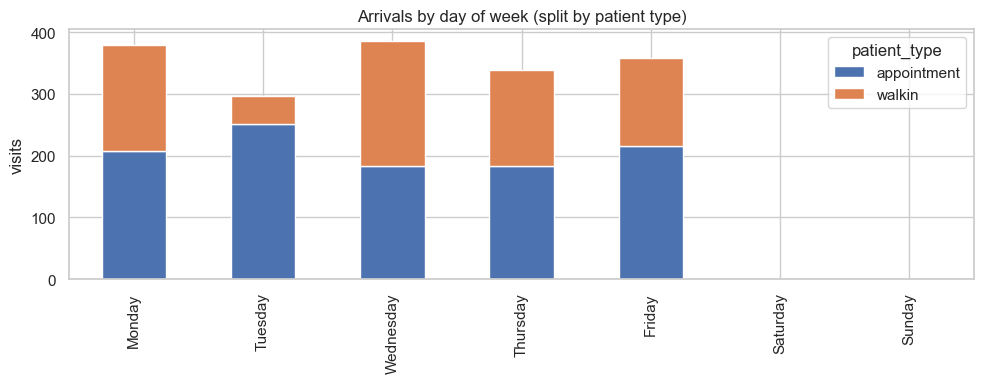

patient_type,appointment,walkin
dow,,
Monday,207.0,172.0
Tuesday,251.0,46.0
Wednesday,184.0,201.0
Thursday,183.0,156.0
Friday,215.0,143.0
Saturday,NaN,NaN
Sunday,NaN,NaN


In [7]:
arrivals = df.dropna(subset=["MUAYENE_KABUL_ZAMANI"]).copy()
arrivals["dow"] = arrivals["MUAYENE_KABUL_ZAMANI"].dt.day_name()
arrivals["hour"] = arrivals["MUAYENE_KABUL_ZAMANI"].dt.hour

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = (
    arrivals.groupby(["dow", "patient_type"]).size().unstack(fill_value=0).reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
dow_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Arrivals by day of week (split by patient type)")
ax.set_ylabel("visits")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUT_DIR / "arrivals_by_dow.png", dpi=150)
plt.show()
dow_counts

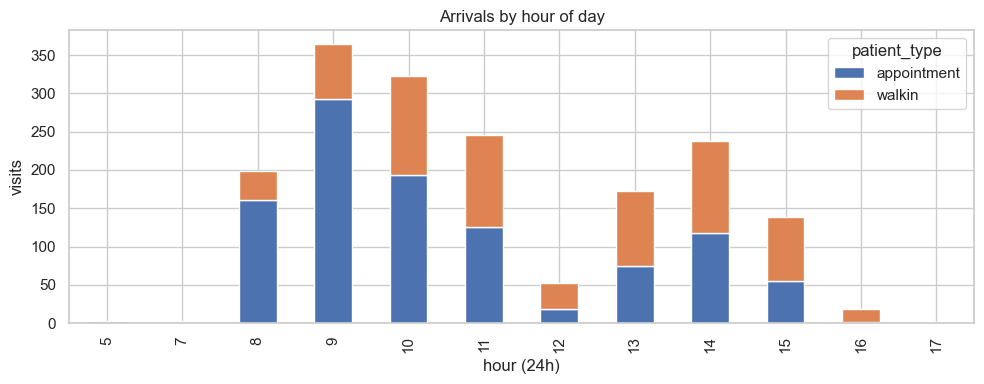

patient_type,appointment,walkin
hour,,
5,0,3
7,1,2
8,161,37
9,293,71
10,193,130
11,126,119
12,18,34
13,74,99
14,117,121


In [8]:
hour_counts = (
    arrivals.groupby(["hour", "patient_type"]).size().unstack(fill_value=0).sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
hour_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Arrivals by hour of day")
ax.set_ylabel("visits")
ax.set_xlabel("hour (24h)")
fig.tight_layout()
fig.savefig(OUT_DIR / "arrivals_by_hour.png", dpi=150)
plt.show()
hour_counts

In [9]:
wed_check = (
    arrivals.assign(is_wed=arrivals["dow"] == "Wednesday")
    .groupby("is_wed")
    .agg(
        visits=("patient_type", "size"),
        walkin_share=("patient_type", lambda s: (s == "walkin").mean()),
        avg_total_minutes=("total_system_time", "mean"),
    )
    .rename(index={True: "Wednesday", False: "Other days"})
)
wed_check

,visits,walkin_share,avg_total_minutes
is_wed,,,
Other days,1373,0.376548,36.074374
Wednesday,385,0.522078,33.462963


In [10]:
ia_walkin = dp.inter_arrival_times(
    df[df["patient_type"] == "walkin"],
    time_column="MUAYENE_KABUL_ZAMANI",
    group_columns=("department",),
)
ia_appt = dp.inter_arrival_times(
    df[df["patient_type"] == "appointment"],
    time_column="RANDEVU_BASLAMA_SAATI",
    group_columns=("department",),
)
ia_walkin["patient_type"] = "walkin"
ia_appt["patient_type"] = "appointment"
inter_arrivals = pd.concat([ia_walkin, ia_appt], ignore_index=True)
inter_arrivals.groupby("patient_type")["inter_arrival_minutes"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
patient_type,,,,,,,,
appointment,800.0,10.05,17.5,0.50,2.38,6.00,10.00,147.00
walkin,691.0,11.36,19.2,0.02,1.92,5.12,11.91,169.32


### 3.1 Department vs day-of-week activity

Quick EDA: how busy is each department on each weekday? We aggregate visits by `(MUAYENE_KABUL_ZAMANI day-of-week, department)` and plot a stacked bar so the report can call out which days the clinic actually runs each polyclinic. This is descriptive only — the fitting in Section 6 still uses pooled samples for arrivals.


In [ ]:
dept_dow = (
    arrivals.groupby(["dow", "department"]).size().unstack(fill_value=0).reindex(dow_order)
)
dept_dow_total = dept_dow.sum(axis=1).rename("total_visits")
dept_dow_summary = dept_dow.assign(total_visits=dept_dow_total)
dept_dow_summary.to_csv(OUT_DIR / "department_by_dow.csv")
display(dept_dow_summary)

fig, ax = plt.subplots(figsize=(11, 5))
dept_dow.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Department workload by day of week (stacked)")
ax.set_ylabel("visits")
ax.set_xlabel("")
ax.legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "department_by_dow.png", dpi=150)
plt.show()


## 4. Routing probabilities

Per-department probability that a patient is sent to the X-ray room (measured as the share of visits with a non-null `TETKIK_ISTEK_SAATI`). This populates `routing.xray_probability` in `config.yml`.

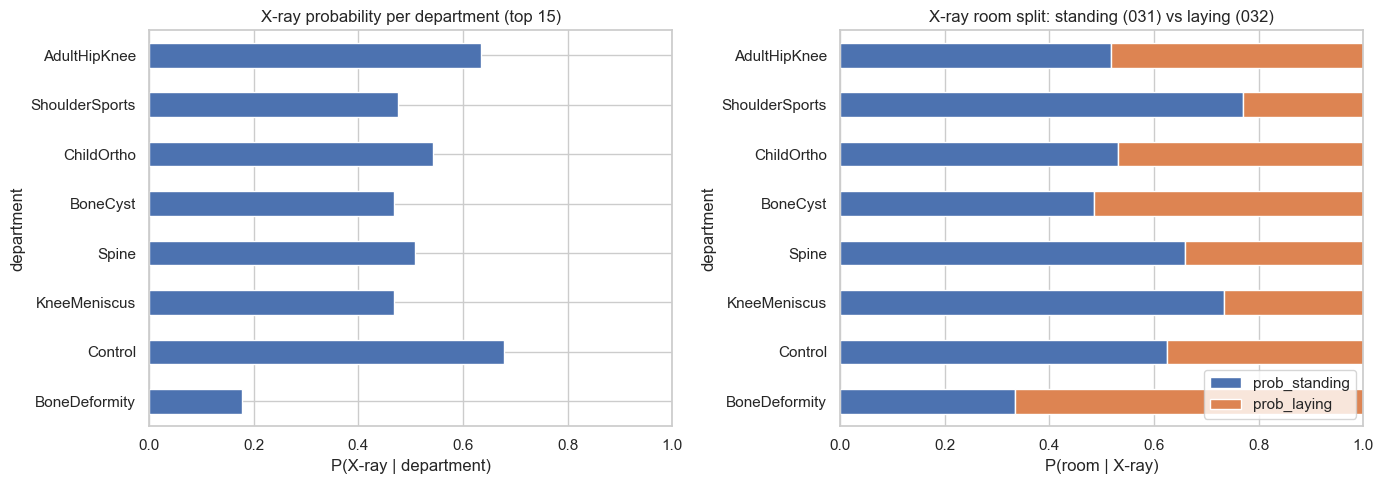

,visits,xray_visits,standing_visits,laying_visits,xray_probability,prob_standing,prob_laying
department,,,,,,,
AdultHipKnee,805,510,263,246,0.634,0.517,0.483
ShoulderSports,311,148,114,34,0.476,0.770,0.230
ChildOrtho,236,128,68,60,0.542,0.531,0.469
BoneCyst,203,95,46,49,0.468,0.484,0.516
Spine,167,85,56,29,0.509,0.659,0.341
KneeMeniscus,64,30,22,8,0.469,0.733,0.267
Control,59,40,25,15,0.678,0.625,0.375
BoneDeformity,17,3,1,2,0.176,0.333,0.667


In [11]:
routing = dp.compute_routing_probabilities(df)
routing.to_csv(OUT_DIR / "routing_probs.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

routing.head(15)["xray_probability"].plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_xlabel("P(X-ray | department)")
axes[0].set_title("X-ray probability per department (top 15)")
axes[0].set_xlim(0, 1)

split_df = routing.head(15)[["prob_standing", "prob_laying"]].fillna(0)
split_df.plot(kind="barh", stacked=True, ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].invert_yaxis()
axes[1].set_xlabel("P(room | X-ray)")
axes[1].set_title("X-ray room split: standing (031) vs laying (032)")
axes[1].set_xlim(0, 1)
axes[1].legend(loc="lower right")

fig.tight_layout()
fig.savefig(OUT_DIR / "routing_probabilities.png", dpi=150)
plt.show()
routing.round(3)

## 5. Service time distributions

Empirical view of the main service times before we commit to a parametric fit. Initial doctor screening is shown twice: visits with an X-ray request vs without. X-ray process (inter-departure) and secondary screening follow. Each plot shows both a histogram (shape) and an empirical CDF (tail behaviour).

### 5a. X-ray service time = consecutive-departure gap

`CEKIM_ZAMANI - TETKIK_ISTEK_SAATI` is actually *request-to-shot wait* (queue + walk time), not service time. We re-estimate service time from the **inter-departure** series: sort `CEKIM_ZAMANI` within each `(_date, xray_room_type)` group and take `.diff()` in minutes.

Queueing argument: while the modality is busy back-to-back, the gap between two consecutive departures equals the second patient's service time. Longer gaps imply the machine went idle (no queue).

**Threshold defence:** the histogram below shows that the vast majority of gaps cluster in the 0-10 minute range; gaps that exceed roughly 25 minutes correspond to the device going idle between shots (lunch breaks, lulls, no queue). We treat `0 < gap <= 25 min` as the service-time sample and discard everything else as idle time. The 25-minute cutoff is reported in `config.yml -> assumptions.xray_service_time_method`.


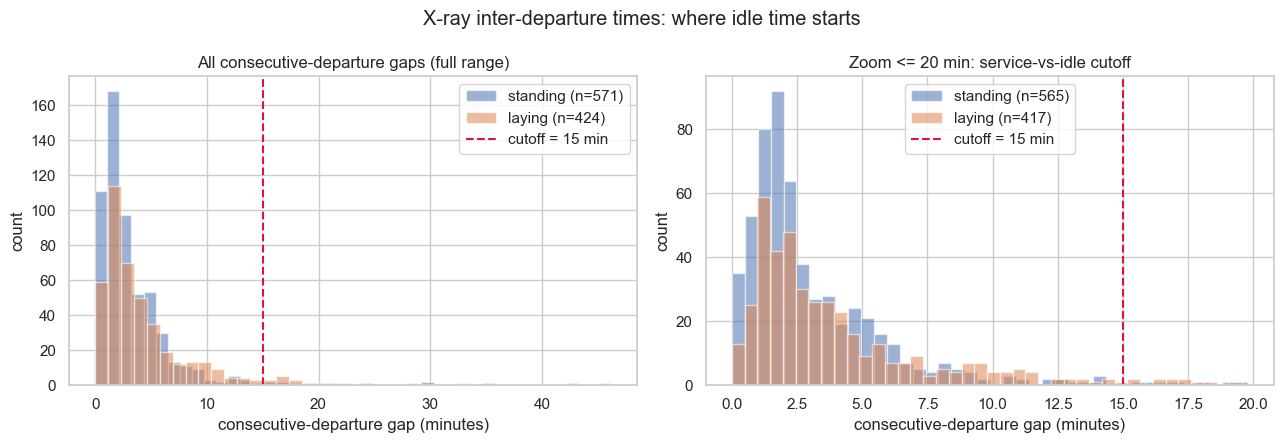

Consecutive-departure gaps: total=1005, kept as service (<= 15 min)=954, discarded as idle=51
  92.2% of gaps are <= 10 min; 95.8% are <= 15 min
Pooled X-ray service sample: n=954, mean=3.29 min, median=2.35 min, p90=7.07 min


,n,min,p25,median,mean,p75,p90,max,std
xray_room,,,,,,,,,
standing,552,0.017,1.333,2.183,2.977,4.037,6.130,14.267,2.529
laying,402,0.017,1.500,2.683,3.719,4.862,8.717,14.600,3.044


In [12]:
XRAY_GAP_CUTOFF = dp.XRAY_INTERDEPARTURE_MAX_MINUTES

xray_diffs = dp.xray_interdeparture_times(df, max_gap_minutes=XRAY_GAP_CUTOFF)
xray_room_samples = dp.xray_samples_by_room(df, max_gap_minutes=XRAY_GAP_CUTOFF)
xray_service_pooled = np.concatenate([xray_room_samples["standing"], xray_room_samples["laying"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, upper, title in [
    (axes[0], 60, "All consecutive-departure gaps (full range)"),
    (axes[1], 20, "Zoom <= 20 min: service-vs-idle cutoff"),
]:
    for room, colour in [("standing", "#4c72b0"), ("laying", "#dd8452")]:
        sample = xray_diffs.loc[xray_diffs["xray_room_type"] == room, "interdeparture_minutes"].to_numpy()
        sample = sample[sample <= upper]
        ax.hist(sample, bins=40, alpha=0.55, label=f"{room} (n={len(sample)})", color=colour)
    ax.axvline(XRAY_GAP_CUTOFF, color="crimson", linestyle="--", linewidth=1.5, label=f"cutoff = {XRAY_GAP_CUTOFF:.0f} min")
    ax.set_xlabel("consecutive-departure gap (minutes)")
    ax.set_ylabel("count")
    ax.set_title(title)
    ax.legend()

fig.suptitle("X-ray inter-departure times: where idle time starts")
fig.tight_layout()
fig.savefig(OUT_DIR / "xray_interdeparture_histogram.png", dpi=150)
plt.show()

total_gaps = len(xray_diffs)
kept_gaps = int(xray_diffs["is_service_sample"].sum())
idle_gaps = total_gaps - kept_gaps
pct_under_10 = float((xray_diffs["interdeparture_minutes"] <= 10).mean() * 100)
pct_under_cutoff = float((xray_diffs["interdeparture_minutes"] <= XRAY_GAP_CUTOFF).mean() * 100)
print(
    f"Consecutive-departure gaps: total={total_gaps}, "
    f"kept as service (<= {XRAY_GAP_CUTOFF:.0f} min)={kept_gaps}, "
    f"discarded as idle={idle_gaps}"
)
print(f"  {pct_under_10:.1f}% of gaps are <= 10 min; {pct_under_cutoff:.1f}% are <= {XRAY_GAP_CUTOFF:.0f} min")
print(
    f"Pooled X-ray service sample: n={len(xray_service_pooled)}, "
    f"mean={xray_service_pooled.mean():.2f} min, median={np.median(xray_service_pooled):.2f} min, "
    f"p90={np.quantile(xray_service_pooled, 0.9):.2f} min"
)

_xray_stat_rows = []
for _room, _arr in [("standing", xray_room_samples["standing"]), ("laying", xray_room_samples["laying"])]:
    _s = pd.Series(_arr, dtype="float64")
    if _s.empty:
        _xray_stat_rows.append(
            {
                "xray_room": _room,
                "n": 0,
                "min": np.nan,
                "p25": np.nan,
                "median": np.nan,
                "mean": np.nan,
                "p75": np.nan,
                "p90": np.nan,
                "max": np.nan,
                "std": np.nan,
            }
        )
    else:
        _xray_stat_rows.append(
            {
                "xray_room": _room,
                "n": int(_s.size),
                "min": float(_s.min()),
                "p25": float(_s.quantile(0.25)),
                "median": float(_s.median()),
                "mean": float(_s.mean()),
                "p75": float(_s.quantile(0.75)),
                "p90": float(_s.quantile(0.9)),
                "max": float(_s.max()),
                "std": float(_s.std()),
            }
        )
xray_service_by_room_stats = pd.DataFrame(_xray_stat_rows).set_index("xray_room")
display(xray_service_by_room_stats.round(3))
xray_service_by_room_stats.round(4).to_csv(OUT_DIR / "xray_service_time_by_room_stats.csv")


In [ ]:
xray_sent_visits = df["TETKIK_ISTEK_SAATI"].notna()
service_samples_raw = {
    "initial_screening_xray": df.loc[xray_sent_visits, "initial_screening_time"].dropna().to_numpy(),
    "single_screening_no_xray": df["single_screening_time"].dropna().to_numpy(),
    "xray_service": xray_service_pooled,
    "secondary_screening_time": df["secondary_screening_time"].dropna().to_numpy(),
}
service_titles = {
    "initial_screening_xray": "Initial screening (X-ray requested)",
    "single_screening_no_xray": "Single screening (no X-ray)",
    "xray_service": "X-ray process (inter-departure, pooled)",
    "secondary_screening_time": "Secondary doctor screening",
}

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax_hist, ax_ecdf, (key, title) in zip(axes[0], axes[1], service_titles.items()):
    samples = service_samples_raw[key]
    if len(samples) == 0:
        ax_hist.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax_hist.transAxes)
        ax_ecdf.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax_ecdf.transAxes)
    else:
        ax_hist.hist(samples, bins=40, color="steelblue", edgecolor="white")
        ax_hist.set_title(f"{title}\n(n={len(samples)}, mean={samples.mean():.2f} min)")
        ax_hist.set_xlabel("minutes")
        ax_hist.set_ylabel("count")
        sorted_s = np.sort(samples)
        ax_ecdf.plot(sorted_s, np.linspace(0, 1, len(sorted_s)))
        ax_ecdf.set_xlabel("minutes")
        ax_ecdf.set_ylabel("ECDF")
        ax_ecdf.set_title(f"ECDF - {title}")
fig.tight_layout()
fig.savefig(OUT_DIR / "service_time_distributions.png", dpi=150)
plt.show()


## 6. Distribution fitting (full goodness-of-fit)

**IQR (Tukey) pre-filter (service times only):** before fitting, keep only positive samples inside `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`. Dropped values are not used in K-S or MLE, but we report *n* before/after in `iqr_filter` inside `config.yml` for transparency in Section 1.4.

For every target variable we:

- Fit six candidate distributions (`expon`, `lognorm`, `gamma`, `weibull_min`, `triang`, `norm`).
- Run a Kolmogorov-Smirnov test and a binned Chi-square test.
- Rank candidates by *accepted at alpha=0.05 first*, then highest K-S p-value, then lowest AIC.

With 300-1700 samples K-S will often reject every theoretical distribution because small shape mismatches become detectable - we therefore also inspect Q-Q plots and AIC to pick the closest-to-reality candidate for the SimPy parameters.

In [ ]:
import re

def _safe_slug(label: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
    return slug or "var"


def fit_and_report(samples: np.ndarray, label: str):
    """Return (fit_table, winner_dict) and save a ranked GoF CSV."""
    table = dp.fit_distributions(samples)
    table.to_csv(OUT_DIR / f"gof_{_safe_slug(label)}.csv", index=False)
    winner = dp.pick_winner(table)
    display_cols = ["candidate", "params", "ks_p", "chi2_p", "aic", "is_accepted"]
    print(f"=== {label} (n={len(samples)}) ===")
    print(f"Winner: {winner['dist']} (K-S p={winner['ks_p']:.4g}, AIC={winner['aic']:.1f})")
    return table[display_cols].round(4), winner


service_fits = {}
iqr_service_report = []

xray_sent_fit = df["TETKIK_ISTEK_SAATI"].notna()
fit_jobs = [
    (
        "initial_screening_xray",
        "Initial screening (X-ray requested)",
        df.loc[xray_sent_fit, "initial_screening_time"].dropna().to_numpy(),
    ),
    (
        "single_screening_no_xray",
        "Single screening (no X-ray)",
        df["single_screening_time"].dropna().to_numpy(),
    ),
    ("xray_service", "X-ray process (inter-departure, pooled)", xray_service_pooled),
    ("secondary_screening_time", "Secondary doctor screening", df["secondary_screening_time"].dropna().to_numpy()),
]

for key, title, raw_samples in fit_jobs:
    samples, iqr_meta = dp.apply_iqr_filter(raw_samples)
    iqr_service_report.append({"variable": key, **iqr_meta})
    print(f"{title}: raw n={iqr_meta['n_before']}, after IQR n={iqr_meta['n_after']}, dropped {iqr_meta['n_before'] - iqr_meta['n_after']}")
    table, winner = fit_and_report(samples, title)
    service_fits[key] = {"table": table, "winner": winner, "n_raw": len(raw_samples), "iqr": iqr_meta}
    display(table)

pd.DataFrame(iqr_service_report).to_csv(OUT_DIR / "iqr_service_times.csv", index=False)

xray_room_fits = {}
for room, raw_arr in xray_room_samples.items():
    samples, iqr_meta = dp.apply_iqr_filter(raw_arr)
    print(f"xray {room}: raw n={iqr_meta['n_before']}, after IQR n={iqr_meta['n_after']}")
    table, winner = fit_and_report(samples, f"xray {room} room")
    xray_room_fits[room] = {"table": table, "winner": winner, "n_raw": len(raw_arr), "iqr": iqr_meta}
    display(table)


In [ ]:
qq_panels: list[tuple[np.ndarray, dict, str]] = []
xray_sent_qq = df["TETKIK_ISTEK_SAATI"].notna()
qq_sources = [
    (
        "initial_screening_xray",
        "Initial screening (X-ray requested)",
        df.loc[xray_sent_qq, "initial_screening_time"].dropna().to_numpy(),
    ),
    (
        "single_screening_no_xray",
        "Single screening (no X-ray)",
        df["single_screening_time"].dropna().to_numpy(),
    ),
    ("xray_service", "X-ray pooled (inter-departure)", xray_service_pooled),
    ("secondary_screening_time", "Secondary screening", df["secondary_screening_time"].dropna().to_numpy()),
]
for key, title, raw_arr in qq_sources:
    emp, _ = dp.apply_iqr_filter(raw_arr)
    qq_panels.append((emp, service_fits[key]["winner"], title))
for room, fit in xray_room_fits.items():
    emp, _ = dp.apply_iqr_filter(xray_room_samples[room])
    qq_panels.append((emp, fit["winner"], f"X-ray {room} room"))

ncols = len(qq_panels)
fig, axes = plt.subplots(1, ncols, figsize=(3.5 * ncols, 4))
for ax, (samples, winner, title) in zip(axes, qq_panels):
    dist = getattr(stats, winner["dist"])
    theoretical = dist.ppf(np.linspace(0.01, 0.99, len(samples)), *winner["params"])
    empirical = np.sort(samples)
    ax.scatter(theoretical, empirical, s=8, alpha=0.6)
    lims = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    ax.plot(lims, lims, color="crimson", linestyle="--", linewidth=1)
    ax.set_xlabel(f"theoretical ({winner['dist']})")
    ax.set_ylabel("empirical (minutes)")
    ax.set_title(title, fontsize=10)
fig.suptitle("Q-Q plots: winning distribution vs data")
fig.tight_layout()
fig.savefig(OUT_DIR / "qq_service_times.png", dpi=150)
plt.show()


### 6a. Department-level service-time fits

Repeat the goodness-of-fit search **for each department** so the SimPy model can sample a different first-exam distribution per polyclinic. Two branches per department:

- `initial_screening_xray` — first-exam time when the patient *is* sent to X-ray (`TETKIK_ISTEK_SAATI` non-null).
- `single_screening_no_xray` — first-exam time when the patient is *not* sent to X-ray (`single_screening_time`).

Departments with too few samples after IQR filtering (`n < 30`) are skipped and should fall back to the pooled fit reported above. Per-branch Q-Q grids are written to `outputs/` as `qq_<dept>.png`.


In [ ]:
DEPT_MIN_N = 30  # below this we keep no winner — caller must use the pooled fit.

dept_jobs = []
for dept_name in df["department"].dropna().unique():
    dept_mask = df["department"] == dept_name
    dept_jobs.append(
        (
            dept_name,
            "initial_screening_xray",
            df.loc[dept_mask & xray_sent_fit, "initial_screening_time"].dropna().to_numpy(),
        )
    )
    dept_jobs.append(
        (
            dept_name,
            "single_screening_no_xray",
            df.loc[dept_mask, "single_screening_time"].dropna().to_numpy(),
        )
    )

dept_service_fits: dict[str, dict] = {}
dept_winner_rows: list[dict] = []

for dept_name, branch_key, raw in dept_jobs:
    samples, iqr_meta = dp.apply_iqr_filter(raw)
    entry: dict = {
        "n_raw": len(raw),
        "n_after_iqr": int(samples.size),
        "iqr": iqr_meta,
        "winner": None,
        "table": None,
    }
    if samples.size < DEPT_MIN_N:
        print(f"[skip] {dept_name} / {branch_key}: n_after_iqr={samples.size} < {DEPT_MIN_N}")
    else:
        table, winner = fit_and_report(samples, f"{dept_name} - {branch_key}")
        entry["table"] = table
        entry["winner"] = winner
    dept_service_fits.setdefault(dept_name, {})[branch_key] = entry

    dept_winner_rows.append(
        {
            "department": dept_name,
            "branch": branch_key,
            "n_raw": len(raw),
            "n_after_iqr": int(samples.size),
            "dist": entry["winner"]["dist"] if entry["winner"] else None,
            "params": entry["winner"]["params"] if entry["winner"] else None,
            "ks_p": entry["winner"]["ks_p"] if entry["winner"] else None,
            "aic": entry["winner"]["aic"] if entry["winner"] else None,
        }
    )

dept_winners_df = pd.DataFrame(dept_winner_rows)
dept_winners_df.to_csv(OUT_DIR / "dept_service_winners.csv", index=False)
display(dept_winners_df.round(4))


In [ ]:
# Per-department Q-Q grid: rows = departments with at least one fit, cols = branches.
branch_titles = {
    "initial_screening_xray": "Initial screening (X-ray)",
    "single_screening_no_xray": "Single screening (no X-ray)",
}
fittable_depts = [
    d for d, branches in dept_service_fits.items()
    if any(b.get("winner") for b in branches.values())
]
if not fittable_depts:
    print("No department had enough samples for a per-department fit — keeping pooled fit.")
else:
    nrows = len(fittable_depts)
    ncols = len(branch_titles)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)
    for r, dept_name in enumerate(fittable_depts):
        for c, (branch_key, branch_title) in enumerate(branch_titles.items()):
            ax = axes[r][c]
            entry = dept_service_fits[dept_name].get(branch_key)
            if entry is None or entry["winner"] is None:
                ax.text(0.5, 0.5, "n/a", ha="center", va="center", transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_title(f"{dept_name} - {branch_title}", fontsize=9)
                continue
            winner = entry["winner"]
            # Re-run IQR filter to recover the empirical sample we fit.
            if branch_key == "initial_screening_xray":
                raw = df.loc[(df["department"] == dept_name) & xray_sent_fit, "initial_screening_time"].dropna().to_numpy()
            else:
                raw = df.loc[df["department"] == dept_name, "single_screening_time"].dropna().to_numpy()
            emp, _ = dp.apply_iqr_filter(raw)
            dist = getattr(stats, winner["dist"])
            theoretical = dist.ppf(np.linspace(0.01, 0.99, len(emp)), *winner["params"])
            empirical = np.sort(emp)
            ax.scatter(theoretical, empirical, s=8, alpha=0.6)
            lims = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
            ax.plot(lims, lims, color="crimson", linestyle="--", linewidth=1)
            ax.set_title(f"{dept_name} - {branch_title}\n{winner['dist']}, n={winner['n']}", fontsize=9)
            ax.set_xlabel("theoretical")
            ax.set_ylabel("empirical (min)")
    fig.suptitle("Q-Q plots: per-department service-time fits", y=1.001)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "qq_service_times_by_department.png", dpi=150)
    plt.show()


### 6b. Inter-arrival with triangular “front door” jitter (walk-in + appointment)

The data only records the time the doctor **accepted** the patient (`MUAYENE_KABUL_ZAMANI`), not the instant they crossed the front door. For **both** walk-ins and patients with a scheduled slot, we add the same `Triangular(-10, 0, +5)` minute offset to `MUAYENE_KABUL_ZAMANI` and fit the resulting inter-arrival series. The assumption is stored as `config.assumptions.walkin_jitter` and `config.assumptions.appointment_jitter` (identical parameters) and should be copied into **Section 1.4 Modelling Assumptions**.

**SimPy release times for appointments** still follow the polyclinic booking grid in `config['arrivals']['appointment']` (named schedules + per-department `schedule_1` / …). The fitted `appointment_inter_arrival` block describes the **empirical** inter-arrival pattern after the same front-door uncertainty; it is complementary to the deterministic schedule, not a replacement for it.

In [16]:
TRI_ARRIVAL_JITTER = stats.triang(c=(0 - (-10)) / (5 - (-10)), loc=-10, scale=15)

walkin_df = df[df["patient_type"] == "walkin"].copy()
jitter = TRI_ARRIVAL_JITTER.rvs(size=len(walkin_df), random_state=RNG)
walkin_df["MUAYENE_KABUL_ZAMANI_JITTERED"] = walkin_df["MUAYENE_KABUL_ZAMANI"] + pd.to_timedelta(jitter, unit="m")

ia_walkin_j = dp.inter_arrival_times(
    walkin_df,
    time_column="MUAYENE_KABUL_ZAMANI_JITTERED",
    group_columns=("department",),
)
walkin_samples = ia_walkin_j["inter_arrival_minutes"].to_numpy()
walkin_table, walkin_winner = fit_and_report(walkin_samples, "walkin inter-arrival")
display(walkin_table)

appt_df = df[df["patient_type"] == "appointment"].dropna(subset=["MUAYENE_KABUL_ZAMANI"]).copy()
jitter_appt = TRI_ARRIVAL_JITTER.rvs(size=len(appt_df), random_state=RNG)
appt_df["MUAYENE_KABUL_ZAMANI_JITTERED"] = appt_df["MUAYENE_KABUL_ZAMANI"] + pd.to_timedelta(jitter_appt, unit="m")

ia_appt_j = dp.inter_arrival_times(
    appt_df,
    time_column="MUAYENE_KABUL_ZAMANI_JITTERED",
    group_columns=("department",),
)
appt_samples = ia_appt_j["inter_arrival_minutes"].to_numpy()
appt_table, appt_winner = fit_and_report(appt_samples, "appointment inter-arrival (jittered kabul)")
display(appt_table)

=== walkin inter-arrival (n=692) ===
Winner: lognorm (K-S p=0.5591, AIC=4590.5)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(1.3618710147038027, -0.10508142350156874, 4.877696711933667)",0.5591,0.2716,4590.4601,True
1,weibull_min,"(0.7294372474166906, 0.009978114033333332, 10.143626945290944)",0.0002,0.0000,4604.6457,False
2,expon,"(0.009978114033333334, 11.350209279697014)",0.0000,0.0000,4750.0629,False
3,norm,"(11.360187393730348, 19.06222349298365)",0.0000,0.0000,6047.4396,False
4,triang,"(0.0021625605415993765, -0.30858512361400514, 168.47138043253335)",0.0000,0.0000,6264.9508,False
5,gamma,"(0.12207375511677052, 0.009978114033333332, 3.2604309657300306)",0.0000,0.0000,9622.0452,False


=== appointment inter-arrival (jittered kabul) (n=1015) ===
Winner: lognorm (K-S p=0.3038, AIC=5729.6)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(1.413219215667712, -0.059402143526258895, 2.8710718817341165)",0.3038,0.0136,5729.5732,True
1,weibull_min,"(0.6872265267706321, 0.001953770066666666, 6.445995350993484)",0.0000,0.0000,5802.9132,False
2,expon,"(0.0019537700666666666, 7.717993138664187)",0.0000,0.0000,6182.4154,False
3,norm,"(7.719946908730853, 17.16141020554607)",0.0000,0.0000,8655.0517,False
4,triang,"(1.124082404191692e-09, 0.0019505583305934925, 167.92005068862068)",0.0000,0.0000,9132.0121,False
5,gamma,"(0.07069452624930544, 0.001953770066666666, 3.1117983302141212)",0.0000,0.0000,12269.1526,False


In [17]:
from simulation import day_slot_times

for sid in ("schedule_1", "schedule_2", "schedule_3"):
    w = APPOINTMENT_SCHEDULES[sid]["windows"]
    n0 = len(day_slot_times(0, w))
    print(f"{sid} slots on first day (from 08:00 anchor in simulation.py): {n0}")

appt_mode = (
    pd.Series(ia_appt["inter_arrival_minutes"].round(0).astype(int))
    .value_counts()
    .head(5)
)
print("(Exploratory) top scheduled inter-arrival *gaps* in the historical data — not used in SimPy, appointments use the YAML grid above.")
print(appt_mode)

schedule_1 slots on first day (from 08:00 anchor in simulation.py): 70
schedule_2 slots on first day (from 08:00 anchor in simulation.py): 53
schedule_3 slots on first day (from 08:00 anchor in simulation.py): 35
(Exploratory) top scheduled inter-arrival *gaps* in the historical data — not used in SimPy, appointments use the YAML grid above.
inter_arrival_minutes
2    140
4     81
8     75
7     72
6     64
Name: count, dtype: int64


## 7. Emit `config.yml`

All the fitted parameters get written to `config.yml` so `simulation.py` (built in the next milestone) can consume them without touching the data. The file is human-readable and can be tweaked manually for what-if scenarios in the Streamlit dashboard.

In [ ]:
def winner_block(winner: dict, *, n_raw: int | None = None, iqr_meta: dict | None = None) -> dict:
    out = {
        "dist": winner["dist"],
        "params": [float(x) for x in winner["params"]],
        "ks_p": float(winner["ks_p"]),
        "aic": float(winner["aic"]),
        "n": int(winner["n"]),
    }
    if n_raw is not None:
        out["n_raw"] = int(n_raw)
    if iqr_meta is not None:
        out["iqr_filter"] = {
            k: (int(v) if k in ("n_before", "n_after", "n_in", "n_outliers") else v)
            for k, v in iqr_meta.items()
        }
    return out


departments = routing.index.tolist()

appointment_arrivals = {
    "mode": "deterministic_schedule",
    "sim_time_zero_is": "08:00_first_day",
    "day_length_minutes": 1440,
    "schedules": APPOINTMENT_SCHEDULES,
    "department_schedules": {dept: "schedule_1" for dept in departments},
}

# Department-level service-time block (Task 4): nested as
# {department: {initial_screening_xray: {...}, single_screening_no_xray: {...}}}.
# Falls back gracefully when a department has too few samples for a fit.
def _dept_block(dept_fits: dict) -> dict:
    block: dict = {}
    for dept, branches in dept_fits.items():
        dept_entry: dict = {}
        for branch_key, branch in branches.items():
            if branch is None or branch.get("winner") is None:
                dept_entry[branch_key] = {
                    "dist": None,
                    "n_raw": int(branch["n_raw"]) if branch else 0,
                    "note": "insufficient samples — fall back to pooled fit",
                }
            else:
                dept_entry[branch_key] = winner_block(
                    branch["winner"],
                    n_raw=branch["n_raw"],
                    iqr_meta=branch["iqr"],
                )
        block[dept] = dept_entry
    return block


config = {
    "resources": {
        "doctors_per_department": {dept: 1 for dept in departments},
        "xray_rooms": {"standing": 1, "laying": 1},
    },
    "routing": {
        "xray_probability": {
            dept: float(round(p, 4))
            for dept, p in routing["xray_probability"].items()
        },
        "xray_room_split": {
            dept: {
                "standing": float(round(row["prob_standing"], 4)) if pd.notna(row["prob_standing"]) else 0.0,
                "laying": float(round(row["prob_laying"], 4)) if pd.notna(row["prob_laying"]) else 0.0,
            }
            for dept, row in routing.iterrows()
        },
    },
    "service_times": {
        "initial_screening": {
            "xray_requested": winner_block(
                service_fits["initial_screening_xray"]["winner"],
                n_raw=service_fits["initial_screening_xray"]["n_raw"],
                iqr_meta=service_fits["initial_screening_xray"]["iqr"],
            ),
            "by_department": _dept_block(
                {dept: {"initial_screening_xray": branches.get("initial_screening_xray")}
                 for dept, branches in dept_service_fits.items()}
            ),
        },
        "single_screening": {
            "no_xray": winner_block(
                service_fits["single_screening_no_xray"]["winner"],
                n_raw=service_fits["single_screening_no_xray"]["n_raw"],
                iqr_meta=service_fits["single_screening_no_xray"]["iqr"],
            ),
            "by_department": _dept_block(
                {dept: {"single_screening_no_xray": branches.get("single_screening_no_xray")}
                 for dept, branches in dept_service_fits.items()}
            ),
        },
        "xray_process": {
            "pooled": winner_block(
                service_fits["xray_service"]["winner"],
                n_raw=service_fits["xray_service"]["n_raw"],
                iqr_meta=service_fits["xray_service"]["iqr"],
            ),
            "standing": winner_block(
                xray_room_fits["standing"]["winner"],
                n_raw=xray_room_fits["standing"]["n_raw"],
                iqr_meta=xray_room_fits["standing"]["iqr"],
            ),
            "laying": winner_block(
                xray_room_fits["laying"]["winner"],
                n_raw=xray_room_fits["laying"]["n_raw"],
                iqr_meta=xray_room_fits["laying"]["iqr"],
            ),
        },
        "secondary_screening": winner_block(
            service_fits["secondary_screening_time"]["winner"],
            n_raw=service_fits["secondary_screening_time"]["n_raw"],
            iqr_meta=service_fits["secondary_screening_time"]["iqr"],
        ),
    },
    "arrivals": {
        "walkin": winner_block(walkin_winner),
        "appointment": appointment_arrivals,
        "appointment_inter_arrival": winner_block(appt_winner),
    },
    "assumptions": {
        "walkin_jitter": {
            "dist": "triang",
            "min_minutes": -10,
            "mode_minutes": 0,
            "max_minutes": 5,
            "note": "Patient crossed the front door somewhere in this window relative to MUAYENE_KABUL_ZAMANI.",
        },
        "appointment_jitter": {
            "dist": "triang",
            "min_minutes": -10,
            "mode_minutes": 0,
            "max_minutes": 5,
            "note": "Same front-door uncertainty as walk-in_jitter, applied to MUAYENE_KABUL_ZAMANI for scheduled patients when fitting inter-arrivals.",
        },
        "follow_up_day": "Wednesday",
        "late_arrival_cutoff": "16:00",
        "scoliosis_room_id": 160,
        "appointment_deviation_hours": 1.0,
        "xray_service_time_method": {
            "definition": "consecutive-departure gap on same (_date, xray_room_type)",
            "idle_cutoff_minutes": float(XRAY_GAP_CUTOFF),
            "note": "Gaps > idle_cutoff_minutes are treated as machine idle time and excluded from the service-time sample.",
        },
    },
}

with open("config.yml", "w", encoding="utf-8") as fh:
    yaml.safe_dump(config, fh, sort_keys=False, allow_unicode=True)
print("Wrote config.yml")
print(yaml.safe_dump(config["service_times"], sort_keys=False, allow_unicode=True))


## 8. QA sanity check

Re-read `config.yml`, draw 10 000 samples from each fitted distribution, and compare the simulated mean/std/quantiles against the empirical values. If any row's ratio is wildly off (> 20% deviation in mean or std) we flag it for manual review before using the config in `simulation.py`.

In [19]:
with open("config.yml", "r", encoding="utf-8") as fh:
    reloaded = yaml.safe_load(fh)

def _emp_iqr(col: str) -> np.ndarray:
    return dp.apply_iqr_filter(df[col].dropna().to_numpy())[0]


def _emp_iqr_initial(mask: pd.Series) -> np.ndarray:
    return dp.apply_iqr_filter(df.loc[mask, "initial_screening_time"].dropna().to_numpy())[0]


qa_xray_route = df["TETKIK_ISTEK_SAATI"].notna()
qa_specs = [
    (
        "service_times.initial_screening.xray_requested",
        reloaded["service_times"]["initial_screening"]["xray_requested"],
        _emp_iqr_initial(qa_xray_route),
    ),
    (
        "service_times.initial_screening.no_xray",
        reloaded["service_times"]["initial_screening"]["no_xray"],
        _emp_iqr_initial(~qa_xray_route),
    ),
    ("service_times.xray_process.pooled", reloaded["service_times"]["xray_process"]["pooled"], dp.apply_iqr_filter(xray_service_pooled)[0]),
    ("service_times.xray_process.standing", reloaded["service_times"]["xray_process"]["standing"], dp.apply_iqr_filter(xray_room_samples["standing"])[0]),
    ("service_times.xray_process.laying", reloaded["service_times"]["xray_process"]["laying"], dp.apply_iqr_filter(xray_room_samples["laying"])[0]),
    ("service_times.secondary_screening", reloaded["service_times"]["secondary_screening"], _emp_iqr("secondary_screening_time")),
    ("arrivals.walkin", reloaded["arrivals"]["walkin"], walkin_samples),
    ("arrivals.appointment_inter_arrival", reloaded["arrivals"]["appointment_inter_arrival"], appt_samples),
]

rows = []
for name, spec, empirical in qa_specs:
    dist = getattr(stats, spec["dist"])
    sim = dist.rvs(*spec["params"], size=10_000, random_state=RNG)
    rows.append(
        {
            "variable": name,
            "dist": spec["dist"],
            "n_empirical": len(empirical),
            "mean_emp": float(np.mean(empirical)),
            "mean_sim": float(np.mean(sim)),
            "std_emp": float(np.std(empirical)),
            "std_sim": float(np.std(sim)),
            "p50_emp": float(np.median(empirical)),
            "p50_sim": float(np.median(sim)),
            "mean_pct_diff": float(abs(np.mean(sim) - np.mean(empirical)) / max(np.mean(empirical), 1e-9) * 100),
        }
    )

qa = pd.DataFrame(rows)
qa["flag"] = qa["mean_pct_diff"].apply(lambda x: "OK" if x < 20 else "REVIEW")
qa.to_csv(OUT_DIR / "qa_sanity_check.csv", index=False)
qa.round(3)

,variable,dist,n_empirical,mean_emp,mean_sim,std_emp,std_sim,p50_emp,p50_sim,mean_pct_diff,flag
0,service_times.initial_screening.xray_requested,lognorm,893,1.167,1.190,0.824,0.989,0.933,0.909,1.967,OK
1,service_times.initial_screening.no_xray,weibull_min,557,4.205,4.179,2.386,2.380,4.017,3.899,0.622,OK
2,service_times.xray_process.pooled,lognorm,895,2.778,2.816,1.954,2.149,2.183,2.293,1.368,OK
3,service_times.xray_process.standing,lognorm,524,2.570,2.586,1.807,1.960,2.017,2.112,0.619,OK
4,service_times.xray_process.laying,gamma,379,3.223,3.203,2.321,2.326,2.517,2.646,0.604,OK
5,service_times.secondary_screening,triang,336,5.200,5.214,1.901,1.842,5.025,5.004,0.272,OK
6,arrivals.walkin,lognorm,692,11.360,12.466,19.062,31.254,5.030,4.806,9.731,OK
7,arrivals.appointment_inter_arrival,lognorm,1015,7.720,7.345,17.161,15.373,2.899,2.729,4.860,OK


## Outputs summary

The `outputs/` folder now contains everything that needs to go into the report:

- `cleaning_audit.csv` - Section 1.3 data-quality table
- `missing_value_heatmap.png`, `arrivals_by_dow.png`, `arrivals_by_hour.png` - Section 1.3 figures
- `service_time_distributions.png`, `qq_service_times.png` - Section 1.3 / 1.4 figures
- `routing_probs.csv`, `routing_probabilities.png` - Section 1.4 / 2.1 routing probabilities
- `gof_*.csv` - one goodness-of-fit table per fitted variable
- `qa_sanity_check.csv` - proof that `config.yml` reproduces the empirical moments

Resolved open items:

1. `DOKTOR_ADI -> department` mapping comes from `Baltalimani_Data_2025.csv` (first-specialty rule). Produces 8 departments plus `Unknown` for the one unlisted doctor.
2. Late-arrival cutoff fixed at 16:00 per the clinic's end-of-day policy.
3. `config.service_times.xray_process` now exposes **three** distributions: `pooled`, `standing`, and `laying`. The simulation can choose the split based on the target patient's modality.
4. `config.service_times.initial_screening` is split into `xray_requested` vs `no_xray`, matching the routing decision (`TETKIK_ISTEK_SAATI` non-null).